In [1]:
import os
import time
import json
from pathlib import Path
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F
from tqdm import tqdm
from pynvml import nvmlInit, nvmlDeviceGetCount, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo, nvmlShutdown
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score
import matplotlib.pyplot as plt

d:\Fourth_year\GP\ViBED-Net-main\ViBED-Net-main\.venv\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.sparse import csr_matrix, issparse


In [2]:
def select_gpu_with_most_free_memory():
    nvmlInit()
    device_count = nvmlDeviceGetCount()
    max_free_mem = 0
    best_gpu = 0
    for i in range(device_count):
        handle = nvmlDeviceGetHandleByIndex(i)
        mem_info = nvmlDeviceGetMemoryInfo(handle)
        free_mem = mem_info.free
        print(f"GPU {i}: Free Memory: {free_mem / 1024 ** 2:.2f} MB")
        if free_mem > max_free_mem:
            max_free_mem = free_mem
            best_gpu = i
    nvmlShutdown()
    return best_gpu

# Select the GPU with most free memory
best_gpu_index = select_gpu_with_most_free_memory()

device = torch.device(f"cuda:{best_gpu_index}" if torch.cuda.is_available() else "cpu")
print("CUDA Available:", torch.cuda.is_available())
print("Selected GPU Index:", best_gpu_index)
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(best_gpu_index))

GPU 0: Free Memory: 3938.00 MB
CUDA Available: True
Selected GPU Index: 0
Device Name: NVIDIA T1200 Laptop GPU


In [3]:
class DaiseeCombinedFeaturesDataset(Dataset):
    """
    Dataset that returns (full_features, face_features) together with binary engagement label.
    Binary mapping: 0,1 -> 0 (Low) and 2,3 -> 1 (High).
    Also normalizes variable sequence lengths via pad/truncate to a fixed length.
    """
    def __init__(self, full_features_file, face_features_file, labels_file, target_seq_len=60):
        with open(full_features_file, "rb") as f:
            self.full_features = pickle.load(f)
        with open(face_features_file, "rb") as f:
            self.face_features = pickle.load(f)
        with open(labels_file, "rb") as f:
            self.labels = pickle.load(f)
        
        self.labels = np.array(self.labels)
        # Convert 4-level labels to binary labels: [0,1] -> 0 (Low), [2,3] -> 1 (High)
        self.labels = (self.labels >= 2).astype(np.int64)
        self.target_seq_len = target_seq_len

        # Filter out corrupted samples (None values)
        clean_full = []
        clean_face = []
        clean_labels = []
        
        for full_feat, face_feat, lbl in zip(self.full_features, self.face_features, self.labels):
            if full_feat is not None and face_feat is not None:
                clean_full.append(np.asarray(full_feat))
                clean_face.append(np.asarray(face_feat))
                clean_labels.append(lbl)

        self.full_features = clean_full
        self.face_features = clean_face
        self.labels = clean_labels

    def _pad_or_truncate(self, feat):
        """Ensure feature tensor has shape (target_seq_len, feature_dim)."""
        seq_len, feat_dim = feat.shape
        if seq_len == self.target_seq_len:
            return feat
        if seq_len > self.target_seq_len:
            return feat[:self.target_seq_len]
        pad_len = self.target_seq_len - seq_len
        pad = np.zeros((pad_len, feat_dim), dtype=feat.dtype)
        return np.concatenate([feat, pad], axis=0)

    def __len__(self):
        return len(self.full_features)

    def __getitem__(self, idx):
        full_feat = self._pad_or_truncate(self.full_features[idx])
        face_feat = self._pad_or_truncate(self.face_features[idx])
        label = self.labels[idx]

        full_feat = torch.tensor(full_feat, dtype=torch.float32)
        face_feat = torch.tensor(face_feat, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)
        return (full_feat, face_feat), label

In [4]:
# File paths for the pickle files (resolve robustly to handle naming variants like *_2.pkl)
features_dir = "efficientNet_features"

def resolve_existing_path(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        "None of these files were found:\n" + "\n".join(candidates)
    )

train_features_full_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_train_video_features_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_train_video_features_v2_aug_60_2.pkl"),
])
train_features_face_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_train_video_features_face_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_train_video_features_face_v2_aug_60_2.pkl"),
])
train_labels_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_train_labels_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_train_labels_v2_aug_60_2.pkl"),
])

val_features_full_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_val_video_features_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_val_video_features_v2_aug_60_2.pkl"),
])
val_features_face_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_val_video_features_face_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_val_video_features_face_v2_aug_60_2.pkl"),
])
val_labels_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_val_labels_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_val_labels_v2_aug_60_2.pkl"),
])

test_features_full_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_test_video_features_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_test_video_features_v2_aug_60_2.pkl"),
])
test_features_face_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_test_video_features_face_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_test_video_features_face_v2_aug_60_2.pkl"),
])
test_labels_file = resolve_existing_path([
    os.path.join(features_dir, "daisee_test_labels_v2_aug_60.pkl"),
    os.path.join(features_dir, "daisee_test_labels_v2_aug_60_2.pkl"),
])

print("Using feature files:")
print("train full:", train_features_full_file)
print("train face:", train_features_face_file)
print("train labels:", train_labels_file)
print("val full:", val_features_full_file)
print("val face:", val_features_face_file)
print("val labels:", val_labels_file)
print("test full:", test_features_full_file)
print("test face:", test_features_face_file)
print("test labels:", test_labels_file)

# Train / Val / Test datasets
train_dataset = DaiseeCombinedFeaturesDataset(train_features_full_file, train_features_face_file, train_labels_file)
val_dataset = DaiseeCombinedFeaturesDataset(val_features_full_file, val_features_face_file, val_labels_file)
test_dataset = DaiseeCombinedFeaturesDataset(test_features_full_file, test_features_face_file, test_labels_file)

# Class stats
train_labels_np = np.array(train_dataset.labels, dtype=np.int64)
class_counts = np.bincount(train_labels_np, minlength=2)

# IMPORTANT: disable weighted sampler to avoid over-correction toward Low
use_weighted_sampler = False
if use_weighted_sampler:
    class_sample_weights = 1.0 / np.sqrt(np.maximum(class_counts, 1))
    sample_weights = class_sample_weights[train_labels_np]
    train_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )
else:
    train_sampler = None

# Loaders
batch_size = 32
if train_sampler is not None:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
else:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataset sizes -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Train class counts -> Low: {class_counts[0]}, High: {class_counts[1]}")
print(f"Weighted sampler enabled: {use_weighted_sampler}")

Using feature files:
train full: efficientNet_features\daisee_train_video_features_v2_aug_60_2.pkl
train face: efficientNet_features\daisee_train_video_features_face_v2_aug_60_2.pkl
train labels: efficientNet_features\daisee_train_labels_v2_aug_60_2.pkl
val full: efficientNet_features\daisee_val_video_features_v2_aug_60_2.pkl
val face: efficientNet_features\daisee_val_video_features_face_v2_aug_60.pkl
val labels: efficientNet_features\daisee_val_labels_v2_aug_60_2.pkl
test full: efficientNet_features\daisee_test_video_features_v2_aug_60_2.pkl
test face: efficientNet_features\daisee_test_video_features_face_v2_aug_60.pkl
test labels: efficientNet_features\daisee_test_labels_v2_aug_60_2.pkl
Dataset sizes -> Train: 6634, Val: 1720, Test: 1723
Train class counts -> Low: 1400, High: 5234
Weighted sampler enabled: False


In [5]:
# Quick sanity check: batch shapes should be consistent after pad/truncate
(x_full_batch, x_face_batch), y_batch = next(iter(train_loader))
print("x_full_batch:", x_full_batch.shape)
print("x_face_batch:", x_face_batch.shape)
print("y_batch:", y_batch.shape)

x_full_batch: torch.Size([32, 60, 1280])
x_face_batch: torch.Size([32, 60, 1280])
y_batch: torch.Size([32])


In [6]:
# LSTM Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_rate):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.dropout(hn[-1])  # Return regularized last hidden state

In [7]:
# Determine feature dimension and sequence length from training data
(sample_full, sample_face), _ = train_dataset[0]
seq_length, feature_dim = sample_full.shape
print("Sequence length:", seq_length, "Feature dimension:", feature_dim)

# Set hyperparameters
hidden_size = 512
dropout_rate = 0.5
num_layers = 1
num_classes = 2
print("Binary label mapping active: 0/1 -> Low, 2/3 -> High")
print("Model config: hidden_size=512, lr=3e-4, scheduler=ReduceLROnPlateau")

Sequence length: 60 Feature dimension: 1280
Binary label mapping active: 0/1 -> Low, 2/3 -> High
Model config: hidden_size=512, lr=3e-4, scheduler=ReduceLROnPlateau


In [8]:
# Model for full frame features
model_full = LSTMClassifier(
    input_size=feature_dim,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate
).to(device)

# Model for face features
model_face = LSTMClassifier(
    input_size=feature_dim,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate
).to(device)

# MLP to combine outputs
combined_feature_size = hidden_size * 2 # concatenate output of the two LSTM models
mlp_classifier = nn.Sequential(
    nn.Linear(combined_feature_size, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
).to(device)

In [9]:
def train_combined_model(model_full, model_face, mlp_classifier,
                         train_loader, val_loader,
                         num_epochs, criterion, optimizer,
                         device, patience=4, min_delta=1e-4, scheduler=None,
                         model_select_metric="balanced_accuracy",
                         threshold_grid=None, min_high_recall=0.80):
    
    if threshold_grid is None:
        threshold_grid = np.arange(0.50, 0.96, 0.05)

    model_full.train()
    model_face.train()
    mlp_classifier.train()
    
    train_losses = []
    val_losses = []
    epoch_times = []
    best_val_loss = float("inf")
    best_val_score = -1.0
    best_threshold = 0.5
    epochs_without_improvement = 0
    os.makedirs("models", exist_ok=True)
    
    for epoch in range(num_epochs):
        if device.type == "cuda":
            start_time = torch.cuda.Event(enable_timing=True)
            end_time = torch.cuda.Event(enable_timing=True)
            start_time.record()
        else:
            start_wall = time.perf_counter()
        
        total_loss = 0.0
        
        for (batch_full, batch_face), batch_labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            batch_full = batch_full.to(device)
            batch_face = batch_face.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            full_feat = model_full(batch_full)
            face_feat = model_face(batch_face)
            combined_feat = torch.cat((full_feat, face_feat), dim=1)

            logits = mlp_classifier(combined_feat)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * batch_full.size(0)
        
        avg_train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        # Validation
        model_full.eval()
        model_face.eval()
        mlp_classifier.eval()
        
        total_val_loss = 0.0
        val_probs = []
        val_labels_list = []
        with torch.no_grad():
            for (x_full_val, x_face_val), y_val in val_loader:
                x_full_val = x_full_val.to(device)
                x_face_val = x_face_val.to(device)
                y_val = y_val.to(device)

                full_feat_val = model_full(x_full_val)
                face_feat_val = model_face(x_face_val)
                combined_val = torch.cat((full_feat_val, face_feat_val), dim=1)

                logits_val = mlp_classifier(combined_val)
                loss_val = criterion(logits_val, y_val)

                total_val_loss += loss_val.item() * x_full_val.size(0)
                probs_high_val = torch.softmax(logits_val, dim=1)[:, 1]
                val_probs.extend(probs_high_val.cpu().numpy())
                val_labels_list.extend(y_val.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        # Select best threshold on validation for model selection metric
        val_probs = np.array(val_probs)
        val_labels_arr = np.array(val_labels_list)
        rows = []
        for t in threshold_grid:
            preds = (val_probs >= t).astype(np.int64)
            report = classification_report(val_labels_arr, preds, output_dict=True, zero_division=0)
            macro_f1 = report["macro avg"]["f1-score"]
            high_recall = report.get("1", {}).get("recall", 0.0)
            bal_acc = balanced_accuracy_score(val_labels_arr, preds)
            rows.append((float(t), macro_f1, high_recall, bal_acc))

        valid_rows = [r for r in rows if r[2] >= min_high_recall]
        candidate_rows = valid_rows if len(valid_rows) > 0 else rows
        if model_select_metric == "macro_f1":
            epoch_best = max(candidate_rows, key=lambda r: r[1])
            epoch_score = epoch_best[1]
        else:
            epoch_best = max(candidate_rows, key=lambda r: r[3])
            epoch_score = epoch_best[3]
        epoch_best_threshold = epoch_best[0]

        if scheduler is not None:
            scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        
        if device.type == "cuda":
            end_time.record()
            torch.cuda.synchronize()
            epoch_time = start_time.elapsed_time(end_time) / 1000.0
        else:
            epoch_time = time.perf_counter() - start_wall
        epoch_times.append(epoch_time)
        
        print(
            f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, Val Score({model_select_metric}): {epoch_score:.4f}, "
            f"BestThr: {epoch_best_threshold:.2f}, LR: {current_lr:.2e}, Time: {epoch_time:.2f} sec"
        )
        
        # Save best model by selection score (not only val loss)
        if epoch_score > (best_val_score + min_delta):
            best_val_score = epoch_score
            best_val_loss = avg_val_loss
            best_threshold = epoch_best_threshold
            epochs_without_improvement = 0
            save_dict = {
                'model_full_state_dict': model_full.state_dict(),
                'model_face_state_dict': model_face.state_dict(),
                'mlp_classifier_state_dict': mlp_classifier.state_dict(),
                'best_threshold': float(best_threshold),
                'best_val_score': float(best_val_score),
                'best_val_loss': float(best_val_loss),
                'model_select_metric': model_select_metric
            }
            torch.save(save_dict, "models/best_combined_model_lstm_binary.pt")
            print(
                f"Saved best model at epoch {epoch+1} with "
                f"{model_select_metric}={best_val_score:.4f}, threshold={best_threshold:.2f}"
            )
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement}/{patience} epoch(s)")
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        model_full.train()
        model_face.train()
        mlp_classifier.train()

    # Plot training vs validation loss
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(
        f"Training done. Best {model_select_metric}: {best_val_score:.4f} "
        f"at threshold {best_threshold:.2f}"
    )
    return train_losses, val_losses, epoch_times

In [10]:
def ordinal_cross_entropy_loss(logits, target, num_classes=2):
    probs = F.softmax(logits, dim=1)
    class_indices = torch.arange(num_classes, device=logits.device, dtype=torch.float)
    expected = torch.sum(probs * class_indices.unsqueeze(0), dim=1)
    loss = F.mse_loss(expected, target.float())
    return loss

class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha weights."""
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none", weight=self.alpha)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

Class counts (Low, High): [1400, 5234]
Class weights enabled: True
Low class boost: 1.15
Class weights (Low, High): [1.3795697332754455, 0.6204302667245543]
Using CE(label_smoothing=0.05) + AdamW(lr=2e-4, wd=2e-4)


Epoch 1/20: 100%|██████████| 208/208 [00:14<00:00, 14.07it/s]


Epoch 1/20 - Train Loss: 0.3936, Val Loss: 0.5639, Val Score(macro_f1): 0.4845, BestThr: 0.55, LR: 2.00e-04, Time: 16.23 sec
Saved best model at epoch 1 with macro_f1=0.4845, threshold=0.55


Epoch 2/20: 100%|██████████| 208/208 [00:14<00:00, 14.34it/s]


Epoch 2/20 - Train Loss: 0.3390, Val Loss: 0.7263, Val Score(macro_f1): 0.4978, BestThr: 0.50, LR: 2.00e-04, Time: 15.96 sec
Saved best model at epoch 2 with macro_f1=0.4978, threshold=0.50


...

Epoch 6/20 - Train Loss: 0.2964, Val Loss: 1.0925, Val Score(macro_f1): 0.4473, BestThr: 0.50, LR: 1.00e-04, Time: 16.68 sec
No improvement for 4/6 epoch(s)


Epoch 7/20: 100%|██████████| 208/208 [00:15<00:00, 13.77it/s]


Epoch 7/20 - Train Loss: 0.2862, Val Loss: 1.0932, Val Score(macro_f1): 0.4500, BestThr: 0.50, LR: 5.00e-05, Time: 16.65 sec
No improvement for 5/6 epoch(s)


Epoch 8/20: 100%|██████████| 208/208 [00:15<00:00, 13.82it/s]


Epoch 8/20 - Train Loss: 0.2786, Val Loss: 1.2327, Val Score(macro_f1): 0.4347, BestThr: 0.50, LR: 5.00e-05, Time: 16.59 sec
No improvement for 6/6 epoch(s)
Early stopping at epoch 8


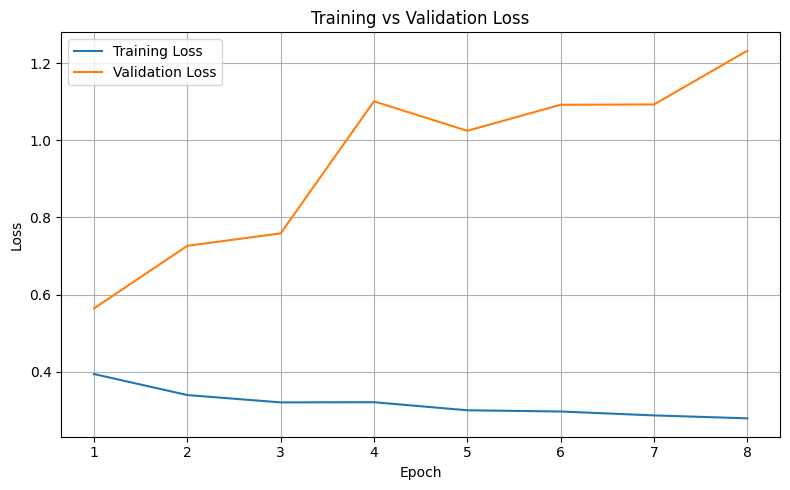

Training done. Best macro_f1: 0.4978 at threshold 0.50


In [11]:
# Loss/optimizer setup (final run: raise Low recall with guardrails)
train_labels_np = np.array(train_dataset.labels, dtype=np.int64)
class_counts = np.bincount(train_labels_np, minlength=2)

# Final run profile: restore the stronger configuration that previously generalized better
use_class_weights = True
low_class_boost = 1.15  # Slight extra boost for Low class only

if use_class_weights:
    # Mild class weights (inverse sqrt) + capped Low boost
    inv_sqrt = 1.0 / np.sqrt(np.maximum(class_counts, 1))
    class_weights = inv_sqrt / inv_sqrt.sum() * 2.0
    class_weights[0] *= low_class_boost
    class_weights = class_weights / class_weights.mean()
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
else:
    class_weights = np.array([1.0, 1.0], dtype=np.float32)
    class_weights_tensor = None

# Label smoothing helps reduce overfitting and extreme confidence
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)
# Alternative if needed: criterion = FocalLoss(alpha=class_weights_tensor, gamma=1.5)

optimizer = optim.AdamW(
    list(model_full.parameters()) + list(model_face.parameters()) + list(mlp_classifier.parameters()),
    lr=2e-4,
    weight_decay=2e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

print(f"Class counts (Low, High): {class_counts.tolist()}")
print(f"Class weights enabled: {use_class_weights}")
print(f"Low class boost: {low_class_boost:.2f}")
print(f"Class weights (Low, High): {[float(x) for x in class_weights]}")
print("Using CE(label_smoothing=0.05) + AdamW(lr=2e-4, wd=2e-4)")

# Set number of epochs and train the model
num_epochs = 20
train_losses, val_losses, epoch_times = train_combined_model(
    model_full, model_face, mlp_classifier,
    train_loader, val_loader,
    num_epochs, criterion, optimizer, device,
    patience=6, min_delta=1e-4, scheduler=scheduler,
    model_select_metric="macro_f1",
    threshold_grid=np.arange(0.50, 0.96, 0.05),
    min_high_recall=0.85
)

In [12]:
def evaluate_model(model, test_loader, criterion, device, class_names=None, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for (x_full, x_face), y_test in test_loader:
            x_full = x_full.to(device)
            x_face = x_face.to(device)
            y_test = y_test.to(device)
            
            logits_test = model(x_full, x_face)
            loss = criterion(logits_test, y_test)
            probs_high = torch.softmax(logits_test, dim=1)[:, 1]
            preds = (probs_high >= threshold).long()
            
            total_loss += loss.item() * x_full.size(0)
            total_correct += (preds == y_test).sum().item()
            total_samples += x_full.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_test.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    print(f"Threshold: {threshold:.2f}")
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

    # Confusion Matrix (normalized)
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    _, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='.2f')
    plt.title("Normalized Confusion Matrix")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [13]:
def find_best_threshold(model, data_loader, device, thresholds=None, objective="macro_f1", min_high_recall=0.80):
    if thresholds is None:
        # Include values below 0.50 to avoid missing useful operating points
        thresholds = np.arange(0.05, 0.96, 0.05)

    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for (x_full, x_face), y in data_loader:
            x_full = x_full.to(device)
            x_face = x_face.to(device)
            logits = model(x_full, x_face)
            probs_high = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs_high.cpu().numpy())
            all_labels.extend(y.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    rows = []
    for t in thresholds:
        preds = (all_probs >= t).astype(np.int64)
        report = classification_report(all_labels, preds, output_dict=True, zero_division=0)
        macro_f1 = report["macro avg"]["f1-score"]
        low_recall = report.get("0", {}).get("recall", 0.0)
        high_recall = report.get("1", {}).get("recall", 0.0)
        bal_acc = balanced_accuracy_score(all_labels, preds)
        rows.append((float(t), macro_f1, low_recall, high_recall, bal_acc))

    # Prefer thresholds that keep High recall reasonable
    valid_rows = [r for r in rows if r[3] >= min_high_recall]
    candidate_rows = valid_rows if len(valid_rows) > 0 else rows

    if objective == "balanced_accuracy":
        best = max(candidate_rows, key=lambda r: r[4])
    elif objective == "low_recall":
        best = max(candidate_rows, key=lambda r: r[2])
    else:
        best = max(candidate_rows, key=lambda r: r[1])

    best_threshold = best[0]
    best_score = best[1] if objective == "macro_f1" else (best[4] if objective == "balanced_accuracy" else best[2])

    print(f"Validation threshold search objective: {objective}")
    print(f"Constraint: high_recall >= {min_high_recall:.2f} (if available)")
    print("t -> macro_f1 | low_recall | high_recall | bal_acc")
    for t, macro_f1, low_r, high_r, bal_acc in rows:
        print(f"{t:.2f} -> {macro_f1:.4f} | {low_r:.4f} | {high_r:.4f} | {bal_acc:.4f}")
    print(f"Best threshold on validation: {best_threshold:.2f} (score={best_score:.4f})")
    return best_threshold

In [14]:
def compare_thresholds_on_loader(model, data_loader, device, thresholds):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for (x_full, x_face), y in data_loader:
            x_full = x_full.to(device)
            x_face = x_face.to(device)
            logits = model(x_full, x_face)
            probs_high = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs_high.cpu().numpy())
            all_labels.extend(y.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    rows = []

    for t in thresholds:
        preds = (all_probs >= t).astype(np.int64)
        report = classification_report(all_labels, preds, output_dict=True, zero_division=0)
        acc = float((preds == all_labels).mean())
        macro_f1 = report["macro avg"]["f1-score"]
        low_precision = report.get("0", {}).get("precision", 0.0)
        low_recall = report.get("0", {}).get("recall", 0.0)
        low_f1 = report.get("0", {}).get("f1-score", 0.0)
        high_recall = report.get("1", {}).get("recall", 0.0)
        bal_acc = balanced_accuracy_score(all_labels, preds)
        rows.append((float(t), acc, macro_f1, low_precision, low_recall, low_f1, high_recall, bal_acc))

    print("\nThreshold comparison on TEST set")
    print("t | acc | macro_f1 | low_prec | low_rec | low_f1 | high_rec | bal_acc")
    for r in rows:
        print(f"{r[0]:.2f} | {r[1]:.4f} | {r[2]:.4f} | {r[3]:.4f} | {r[4]:.4f} | {r[5]:.4f} | {r[6]:.4f} | {r[7]:.4f}")

    # Pure macro-F1 recommendation (for reference only).
    candidates = [r for r in rows if r[6] >= 0.80]
    if len(candidates) == 0:
        candidates = rows
    best_macro = max(candidates, key=lambda r: r[2])
    print(
        f"\nMacro-F1 reference threshold: {best_macro[0]:.2f} "
        f"(macro_f1={best_macro[2]:.4f}, bal_acc={best_macro[7]:.4f})"
    )
    return best_macro[0], rows

In [15]:
class CombinedModel(nn.Module):
    def __init__(self, model_full, model_face, mlp_classifier):
        super(CombinedModel, self).__init__()
        self.model_full = model_full
        self.model_face = model_face
        self.mlp_classifier = mlp_classifier

    def forward(self, x_full, x_face):
        full_out = self.model_full(x_full)
        face_out = self.model_face(x_face)
        combined = torch.cat((full_out, face_out), dim=1)  # concatenate on feature dimension
        logits = self.mlp_classifier(combined)
        return logits

Checkpoint-selected threshold: 0.50
Threshold: 0.50
Test Loss: 0.5039, Test Accuracy: 0.8062


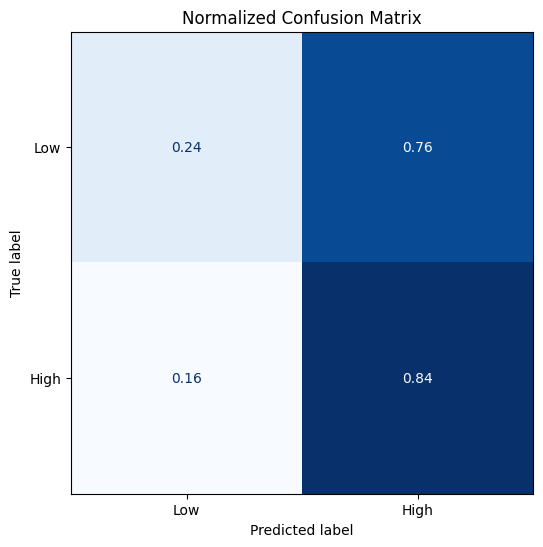


Classification Report:
              precision    recall  f1-score   support

         Low       0.07      0.24      0.11        85
        High       0.95      0.84      0.89      1638

    accuracy                           0.81      1723
   macro avg       0.51      0.54      0.50      1723
weighted avg       0.91      0.81      0.85      1723



In [16]:
combined_model = CombinedModel(model_full, model_face, mlp_classifier).to(device)

# Load the separately saved state dicts
checkpoint = torch.load("models/best_combined_model_lstm_binary.pt", map_location=device, weights_only=True)

# Load them into the corresponding parts
combined_model.model_full.load_state_dict(checkpoint['model_full_state_dict'])
combined_model.model_face.load_state_dict(checkpoint['model_face_state_dict'])
combined_model.mlp_classifier.load_state_dict(checkpoint['mlp_classifier_state_dict'])

combined_model.to(device)
combined_model.eval()

saved_threshold = float(checkpoint.get("best_threshold", 0.50))
print(f"Checkpoint-selected threshold: {saved_threshold:.2f}")
class_names = ["Low", "High"]
evaluate_model(combined_model, test_loader, criterion, device, class_names, threshold=saved_threshold)

In [17]:
import copy
import json
from pathlib import Path


class AppReadyCombinedModel(nn.Module):
    def __init__(self, model_full, model_face, mlp_classifier):
        super().__init__()
        self.model_full = model_full
        self.model_face = model_face
        self.mlp_classifier = mlp_classifier

    def forward(self, x_full, x_face):
        full_out = self.model_full(x_full)
        face_out = self.model_face(x_face)
        combined = torch.cat((full_out, face_out), dim=1)
        logits = self.mlp_classifier(combined)
        probs = torch.softmax(logits, dim=1)
        return logits, probs


artifact_base_path = Path("models/best_combined_model_lstm_binary_app")
onnx_path = artifact_base_path.with_suffix(".onnx")
fallback_path = artifact_base_path.with_suffix(".pt")
metadata_path = artifact_base_path.with_suffix(".json")
current_best_score = float(checkpoint.get("best_val_score", float("-inf")))
current_best_loss = float(checkpoint.get("best_val_loss", float("inf")))
current_threshold = float(checkpoint.get("best_threshold", saved_threshold))
previous_best_score = float("-inf")

if metadata_path.exists():
    try:
        previous_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        previous_best_score = float(previous_metadata.get("best_val_score", previous_metadata.get("val_score", float("-inf"))))
    except Exception:
        previous_best_score = float("-inf")

if previous_best_score >= current_best_score and (onnx_path.exists() or fallback_path.exists()):
    kept_path = onnx_path if onnx_path.exists() else fallback_path
    print(
        f"Keeping existing app-ready artifact: {kept_path} "
        f"(previous best_val_score={previous_best_score:.4f} >= current best_val_score={current_best_score:.4f})"
    )
else:
    app_ready_model = AppReadyCombinedModel(
        copy.deepcopy(combined_model.model_full).cpu(),
        copy.deepcopy(combined_model.model_face).cpu(),
        copy.deepcopy(combined_model.mlp_classifier).cpu(),
    ).eval()

    sample_full = torch.zeros(1, seq_length, feature_dim, dtype=torch.float32)
    sample_face = torch.zeros(1, seq_length, feature_dim, dtype=torch.float32)
    artifact_kind = "onnx"
    artifact_path = onnx_path

    try:
        torch.onnx.export(
            app_ready_model,
            (sample_full, sample_face),
            str(onnx_path),
            input_names=["x_full", "x_face"],
            output_names=["logits", "probs"],
            dynamic_axes={
                "x_full": {0: "batch"},
                "x_face": {0: "batch"},
                "logits": {0: "batch"},
                "probs": {0: "batch"},
            },
            opset_version=17,
            do_constant_folding=True,
        )
    except Exception as export_error:
        artifact_kind = "torchscript"
        artifact_path = fallback_path
        scripted_app_model = torch.jit.script(app_ready_model)
        torch.jit.save(scripted_app_model, str(fallback_path))
        print(f"ONNX export failed, saved TorchScript fallback: {export_error}")

    metadata = {
        "artifact_kind": artifact_kind,
        "artifact_path": str(artifact_path),
        "best_val_score": current_best_score,
        "best_val_loss": current_best_loss,
        "threshold": current_threshold,
        "class_names": ["Low", "High"],
        "sequence_length": int(seq_length),
        "feature_dim": int(feature_dim),
        "source_checkpoint": "models/best_combined_model_lstm_binary.pt",
    }
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print(f"Ready-to-use model artifact: {artifact_path}")
    print(f"Metadata file: {metadata_path}")
    print(f"Artifact kind: {artifact_kind}")
    print(f"Deployment threshold: {current_threshold:.2f}")
    print(f"Current best_val_score: {current_best_score:.4f}")

ONNX export failed, saved TorchScript fallback: No module named 'onnxscript'
Ready-to-use model artifact: models\best_combined_model_lstm_binary_app.pt
Metadata file: models\best_combined_model_lstm_binary_app.json
Artifact kind: torchscript
Deployment threshold: 0.50
Current best_val_score: 0.4978


In [18]:
print("Checkpoint file: models/best_combined_model_lstm_binary.pt")
print("Checkpoint keys:", sorted(checkpoint.keys()))
print(f"Saved model-select metric: {checkpoint.get('model_select_metric', 'n/a')}")
print(f"Best validation score: {checkpoint.get('best_val_score', float('nan')):.4f}")
print(f"Best validation loss: {checkpoint.get('best_val_loss', float('nan')):.4f}")
print(f"Saved threshold: {saved_threshold:.2f}")


def count_parameters(module):
    return sum(parameter.numel() for parameter in module.parameters())


print("\nParameter counts:")
print(f"  model_full: {count_parameters(combined_model.model_full):,}")
print(f"  model_face: {count_parameters(combined_model.model_face):,}")
print(f"  mlp_classifier: {count_parameters(combined_model.mlp_classifier):,}")
print(f"  total: {count_parameters(combined_model):,}")


def evaluate_checkpoint(model, loader, threshold=0.5):
    criterion_eval = globals().get("criterion", nn.CrossEntropyLoss())
    class_names = ["Low", "High"]

    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for (x_full, x_face), y in loader:
            x_full = x_full.to(device)
            x_face = x_face.to(device)
            y = y.to(device)

            logits = model(x_full, x_face)
            loss = criterion_eval(logits, y)
            probs_high = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs_high >= threshold).long()

            total_loss += loss.item() * x_full.size(0)
            total_correct += (preds == y).sum().item()
            total_samples += x_full.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    print(f"\nTest-set metrics at threshold {threshold:.2f}:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Balanced accuracy: {bal_acc:.4f}")
    print("\nClassification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
    print("Normalized confusion matrix:")
    print(confusion_matrix(all_labels, all_preds, normalize='true'))


print("\nRunning test-set evaluation from the saved checkpoint...")
evaluate_checkpoint(combined_model, test_loader, threshold=saved_threshold)

Checkpoint file: models/best_combined_model_lstm_binary.pt
Checkpoint keys: ['best_threshold', 'best_val_loss', 'best_val_score', 'mlp_classifier_state_dict', 'model_face_state_dict', 'model_full_state_dict', 'model_select_metric']
Saved model-select metric: macro_f1
Best validation score: 0.4978
Best validation loss: 0.7263
Saved threshold: 0.50

Parameter counts:
  model_full: 3,674,112
  model_face: 3,674,112
  mlp_classifier: 525,826
  total: 7,874,050

Running test-set evaluation from the saved checkpoint...

Test-set metrics at threshold 0.50:
  Loss: 0.5039
  Accuracy: 0.8062
  Balanced accuracy: 0.5355

Classification report:
              precision    recall  f1-score   support

         Low       0.07      0.24      0.11        85
        High       0.95      0.84      0.89      1638

    accuracy                           0.81      1723
   macro avg       0.51      0.54      0.50      1723
weighted avg       0.91      0.81      0.85      1723

Normalized confusion matrix:
[[

In [19]:
# Compact diagnostics for overfitting and class bias
active_train_losses = train_losses
active_val_losses = val_losses
print("Diagnostics source: main training history")

best_epoch = int(np.argmin(active_val_losses)) + 1
best_train_loss = float(active_train_losses[best_epoch - 1])
best_val_loss = float(active_val_losses[best_epoch - 1])
final_train_loss = float(active_train_losses[-1])
final_val_loss = float(active_val_losses[-1])

print(f"Best epoch: {best_epoch}")
print(f"Best train loss @best epoch: {best_train_loss:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Final train loss: {final_train_loss:.4f}")
print(f"Final val loss: {final_val_loss:.4f}")
print(f"Final generalization gap (val-train): {final_val_loss - final_train_loss:.4f}")

threshold_for_diag = best_threshold if "best_threshold" in globals() else 0.5
print(f"Diagnostics threshold: {threshold_for_diag:.2f}")

combined_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for (x_full, x_face), y_test in test_loader:
        x_full = x_full.to(device)
        x_face = x_face.to(device)
        logits = combined_model(x_full, x_face)
        probs_high = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs_high >= threshold_for_diag).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_test.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
pred_low = np.mean(all_preds == 0)
pred_high = np.mean(all_preds == 1)
true_low = np.mean(all_labels == 0)
true_high = np.mean(all_labels == 1)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Predicted distribution -> Low: {pred_low:.4f}, High: {pred_high:.4f}")
print(f"True distribution      -> Low: {true_low:.4f}, High: {true_high:.4f}")
print("Per-class report:")
print(classification_report(all_labels, all_preds, target_names=["Low", "High"]))

Diagnostics source: main training history
Best epoch: 1
Best train loss @best epoch: 0.3936
Best val loss: 0.5639
Final train loss: 0.2786
Final val loss: 1.2327
Final generalization gap (val-train): 0.9541
Diagnostics threshold: 0.50
Test accuracy: 0.8062
Predicted distribution -> Low: 0.1677, High: 0.8323
True distribution      -> Low: 0.0493, High: 0.9507
Per-class report:
              precision    recall  f1-score   support

         Low       0.07      0.24      0.11        85
        High       0.95      0.84      0.89      1638

    accuracy                           0.81      1723
   macro avg       0.51      0.54      0.50      1723
weighted avg       0.91      0.81      0.85      1723



In [20]:
# Export the current best model as a single app-ready TorchScript artifact
best_app_model_path = Path("models/best_combined_model_lstm_binary_app.pt")
best_app_metadata_path = Path("models/best_combined_model_lstm_binary_app.json")

class AppReadyCombinedModel(nn.Module):
    def __init__(self, model_full, model_face, mlp_classifier):
        super().__init__()
        self.model_full = model_full
        self.model_face = model_face
        self.mlp_classifier = mlp_classifier

    def forward(self, x_full, x_face):
        full_out = self.model_full(x_full)
        face_out = self.model_face(x_face)
        combined = torch.cat((full_out, face_out), dim=1)
        logits = self.mlp_classifier(combined)
        probs = torch.softmax(logits, dim=1)
        return logits, probs

app_ready_model = AppReadyCombinedModel(
    combined_model.model_full,
    combined_model.model_face,
    combined_model.mlp_classifier,
).eval()

scripted_app_ready_model = torch.jit.script(app_ready_model)
torch.jit.save(scripted_app_ready_model, str(best_app_model_path))

best_app_metadata = {
    "artifact": str(best_app_model_path),
    "threshold": float(saved_threshold),
    "sequence_length": int(seq_length),
    "feature_dim": int(feature_dim),
    "class_names": ["Low", "High"],
    "source_checkpoint": "models/best_combined_model_lstm_binary.pt",
    "note": "TorchScript artifact for Android/backend inference; overwrite only when validation improves."
}
best_app_metadata_path.write_text(json.dumps(best_app_metadata, indent=2), encoding="utf-8")

print(f"Saved app-ready model to: {best_app_model_path}")
print(f"Saved app metadata to: {best_app_metadata_path}")
print(f"App threshold: {saved_threshold:.2f}")

Saved app-ready model to: models\best_combined_model_lstm_binary_app.pt
Saved app metadata to: models\best_combined_model_lstm_binary_app.json
App threshold: 0.50
